# Telecom Churn Prediction


🔹 Model 1: Logistic Regression with PCA
Accuracy: 0.8981904761904762
Precision: 0.5166666666666667
Recall: 0.014485981308411215
ROC AUC: 0.7942266429470471
              precision    recall  f1-score   support

           0       0.90      1.00      0.95     18860
           1       0.52      0.01      0.03      2140

    accuracy                           0.90     21000
   macro avg       0.71      0.51      0.49     21000
weighted avg       0.86      0.90      0.85     21000



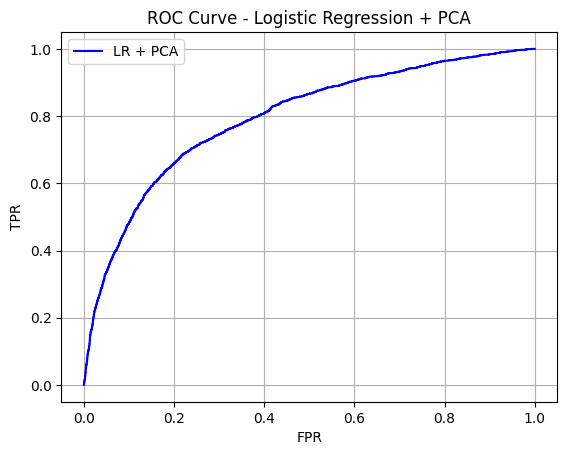


🔹 Model 2: Random Forest Classifier
Accuracy: 0.9402857142857143
Precision: 0.7903014416775884
Recall: 0.5635514018691589
ROC AUC: 0.9279475674175677
              precision    recall  f1-score   support

           0       0.95      0.98      0.97     18860
           1       0.79      0.56      0.66      2140

    accuracy                           0.94     21000
   macro avg       0.87      0.77      0.81     21000
weighted avg       0.94      0.94      0.94     21000



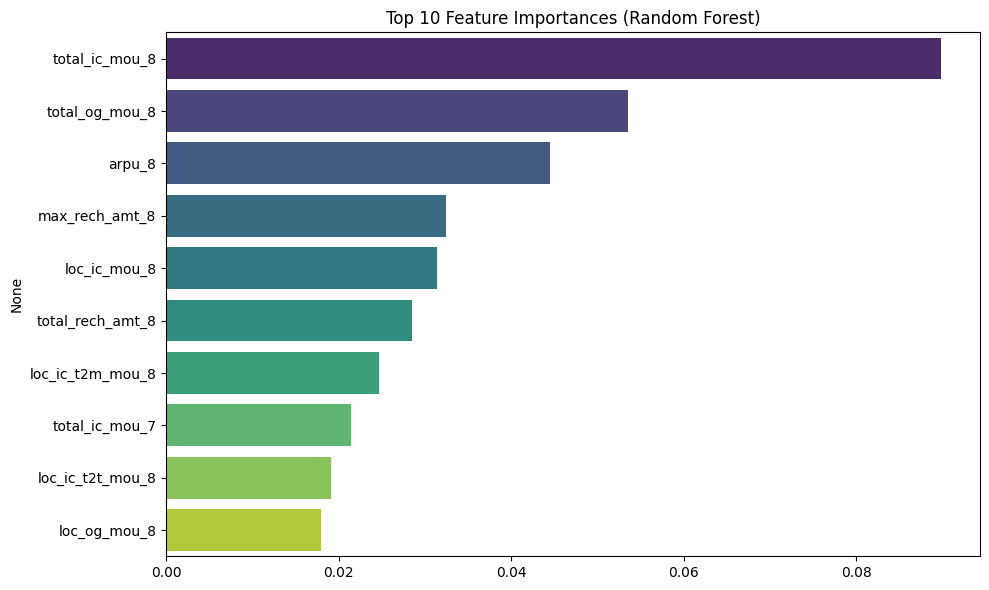


🔹 Model 3: Logistic Regression (No PCA)
Accuracy: 0.9298095238095239
Precision: 0.7841296928327645
Recall: 0.4294392523364486
ROC AUC: 0.9083358688219144
              precision    recall  f1-score   support

           0       0.94      0.99      0.96     18860
           1       0.78      0.43      0.55      2140

    accuracy                           0.93     21000
   macro avg       0.86      0.71      0.76     21000
weighted avg       0.92      0.93      0.92     21000



In [1]:
# ✅ Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    precision_score, recall_score, roc_auc_score,
    roc_curve
)

warnings.filterwarnings("ignore")


df = pd.read_csv("train.csv")

assert 'churn_probability' in df.columns, "ERROR: 'churn_probability' column not found."

df.fillna(df.median(numeric_only=True), inplace=True)

X = df.drop(columns=["churn_probability"])
y = df["churn_probability"]

numeric_cols = X.select_dtypes(include=["int", "float"]).columns
X = X[numeric_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

n_samples, n_features = X_train_scaled.shape
max_components = min(10, n_samples, n_features)

if max_components < 1:
    raise ValueError("Not enough data or features to perform PCA")

pca = PCA(n_components=max_components, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

lr_pca = LogisticRegression(max_iter=1000)
lr_pca.fit(X_train_pca, y_train)

y_pred_pca = lr_pca.predict(X_test_pca)
y_proba_pca = lr_pca.predict_proba(X_test_pca)[:, 1]

print("\n🔹 Model 1: Logistic Regression with PCA")
print("Accuracy:", accuracy_score(y_test, y_pred_pca))
print("Precision:", precision_score(y_test, y_pred_pca))
print("Recall:", recall_score(y_test, y_pred_pca))
print("ROC AUC:", roc_auc_score(y_test, y_proba_pca))
print(classification_report(y_test, y_pred_pca))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba_pca)
plt.figure()
plt.plot(fpr, tpr, label="LR + PCA", color='blue')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve - Logistic Regression + PCA")
plt.legend()
plt.grid(True)
plt.show()

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("\n🔹 Model 2: Random Forest Classifier")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_proba_rf))
print(classification_report(y_test, y_pred_rf))

# Feature Importance Plot
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp.values[:10], y=feat_imp.index[:10], palette="viridis")
plt.title("Top 10 Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()

lr_raw = LogisticRegression(max_iter=1000)
lr_raw.fit(X_train_scaled, y_train)

y_pred_raw = lr_raw.predict(X_test_scaled)
y_proba_raw = lr_raw.predict_proba(X_test_scaled)[:, 1]

print("\n🔹 Model 3: Logistic Regression (No PCA)")
print("Accuracy:", accuracy_score(y_test, y_pred_raw))
print("Precision:", precision_score(y_test, y_pred_raw))
print("Recall:", recall_score(y_test, y_pred_raw))
print("ROC AUC:", roc_auc_score(y_test, y_proba_raw))
print(classification_report(y_test, y_pred_raw))



